# 0) Setup & Imports

In [1]:
# Cell 0 — Setup & Imports
import re, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from collections import Counter, defaultdict

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import QuantileTransformer, StandardScaler
from sklearn.feature_selection import mutual_info_regression
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.impute import SimpleImputer
from IPython.display import display
from scipy.stats import spearmanr

from xgboost import XGBRegressor

# 1) Load Data (Table1) 

In [2]:
# Cell 1 — Load
file = "Financial_data.xlsx"  
sheet = "Tabelle1"

df = pd.read_excel(file, sheet_name=sheet)
df_raw = df.copy()

print(df.shape)
df.head(3)

(4392, 225)


,Unnamed: 0,Revenue,Revenue Growth,Cost of Revenue,Gross Profit,R&D Expenses,SG&A Expense,Operating Expenses,Operating Income,Interest Expense,...,Receivables growth,Inventory Growth,Asset Growth,Book Value per Share Growth,Debt Growth,R&D Expense Growth,SG&A Expenses Growth,Sector,2019 PRICE VAR [%],Class
0,CMCSA,9.450700e+10,0.1115,0.000000e+00,9.450700e+10,0.000000e+00,6.482200e+10,7.549800e+10,1.900900e+10,3.542000e+09,...,257,0.0,0.3426,0.0722,0.7309,0.0,0.1308,Consumer Cyclical,3.279457e+15,1
1,KMI,1.414400e+10,32,7.288000e+09,6.856000e+09,0.000000e+00,6.010000e+08,3.062000e+09,3.794000e+09,1.917000e+09,...,0.0345,-92,-0.0024,0.0076,-0.0137,0.0,-0.1265,Energy,4.058807e+15,1
2,INTC,7.084800e+10,0.1289,2.711100e+10,4.373700e+10,1.354300e+10,6.750000e+09,2.042100e+10,2.331600e+10,-1.260000e+08,...,0.1989,0.0387,0.0382,0.1014,-0.0169,39,-0.0942,Technology,3.029551e+16,1


# 2) Convertio to numeric 

In [3]:
# Cell 2 — robust numeric parser
def clean_numeric(val):
    if pd.isna(val): 
        return np.nan
    s = str(val).strip()

    # negative in Klammern (z. B. "(1,234.5)")
    neg = False
    if s.startswith("(") and s.endswith(")"):
        neg = True
        s = s[1:-1]

    # Prozent
    is_pct = False
    if s.endswith("%"):
        is_pct = True
        s = s[:-1]

    # nur Ziffern/./,/−/E
    s = re.sub(r"[^0-9,.\-Ee]", "", s)

    # Tausender/Dezimal-Heuristik
    if "," in s and "." in s:
        s = s.replace(",", "")
    elif "," in s and "." not in s:
        s = s.replace(",", ".")

    try:
        x = float(s)
    except:
        return np.nan

    if neg: x = -x
    if is_pct: x = x / 100.0
    return x

# Anwenden auf object-Spalten
df_clean = df.copy()
obj_cols = df_clean.select_dtypes(include="object").columns.tolist()
if obj_cols:
    df_clean[obj_cols] = df_clean[obj_cols].applymap(clean_numeric)

# Kontrolle
num_cols = df_clean.select_dtypes(include=np.number).columns.tolist()
non_num = [c for c in df_clean.columns if c not in num_cols]
print(f"Numerisch: {len(num_cols)} | Nicht-numerisch: {len(non_num)}")

Numerisch: 225 | Nicht-numerisch: 0


# 3) Data Cleansing

In [4]:
# Cell 3 — Meta weg, NA-Filter
dfw = df_clean.copy()

# Meta/IDs raus vor NA-Profil
meta_cols = [c for c in ["Unnamed: 0","Ticker","Company","Name","ISIN","CUSIP","Symbol","Class"] if c in dfw.columns]
dfw = dfw.drop(columns=meta_cols, errors="ignore")

# NA-Profil
na_profile = pd.DataFrame({
    "na_cnt": dfw.isna().sum(),
    "na_pct": (dfw.isna().mean()*100).round(2),
    "dtype": dfw.dtypes.astype(str)
}).sort_values("na_pct", ascending=False)

COL_NA_MAX = 40.0   # % Spalten
ROW_NA_MAX = 30.0   # % Zeilen

cols_bad = na_profile[na_profile["na_pct"] > COL_NA_MAX].index.tolist()
if cols_bad:
    dfw = dfw.drop(columns=cols_bad, errors="ignore")

# Zeilenfilter NACH Spaltenfilter
row_na_pct = (dfw.isna().mean(axis=1) * 100)
rows_bad = row_na_pct[row_na_pct > ROW_NA_MAX].index.tolist()
if len(rows_bad):
    dfw = dfw.drop(index=rows_bad)
print(na_profile)
print("Shape nach NA-Filtern:", dfw.shape)

                                na_cnt  na_pct    dtype
Sector                            4392  100.00  float64
cashConversionCycle               4386   99.86  float64
operatingCycle                    4386   99.86  float64
shortTermCoverageRatios           1938   44.13  float64
EPS                               1764   40.16  float64
...                                ...     ...      ...
Long-term debt                      30    0.68  float64
Net cash flow / Change in cash      24    0.55  float64
Retained earnings (deficit)         21    0.48  float64
Financing Cash Flow                 19    0.43  float64
2019 PRICE VAR [%]                   0    0.00  float64

[223 rows x 3 columns]
Shape nach NA-Filtern: (4135, 218)


# 4) Set and validate the target variable;remove leakage from X

In [5]:
# Cell 4 — Target & Features (ohne Leakage)
TARGET = "Market Cap"
if TARGET not in dfw.columns:
    raise KeyError(f"'{TARGET}' nicht gefunden")

# Zielwerte validieren (nicht-negativ & non-NaN)
y_raw = dfw[TARGET].copy()
mask_target_valid = y_raw.notna() & (y_raw >= 0)
dfw = dfw.loc[mask_target_valid].copy()
y_raw = y_raw.loc[mask_target_valid].copy()

# log1p-Target
y = np.log1p(y_raw)

# Feature-Matrix ohne Leckage
leak_cols = ["Market Cap", "Enterprise Value"]
X = dfw.drop(columns=[c for c in leak_cols if c in dfw.columns], errors="ignore")

print("X/y shapes:", X.shape, y.shape)

X/y shapes: (3954, 216) (3954,)


# 5) Delete exact and almost Duplicates

In [6]:
# Cell 5 — Namen säubern & redundante Spalten
def clean_name(s):
    s = str(s)
    s = re.sub(r"[()\[\]<>]", "", s)
    s = s.replace("%","pct").replace("&","and").replace("/", "_per_").replace("-", "_").replace(".", "_")
    s = re.sub(r"\s+", "_", s)
    s = re.sub(r"_+", "_", s).strip("_")
    return s

# 5.1 exakte Duplikate (spaltenweise)
X0 = X.loc[:, ~X.T.duplicated()]

# 5.2 quasi-Duplikate (|r|≈1) — nachher auf TRAIN nochmal sicher
# (hier nur ein erster grober Pass auf Gesamtdaten, das ECHTE Entscheiden machen wir später train-only)
corr0 = X0.corr()
to_drop0 = set()
TOL0 = 0.999999
cols0 = corr0.columns
for i in range(len(cols0)):
    for j in range(i):
        r = corr0.iat[i, j]
        if np.isfinite(r) and abs(r) >= TOL0:
            to_drop0.add(cols0[i])
X0 = X0.drop(columns=list(to_drop0), errors="ignore")

# 5.3 Spaltennamen säubern
old_cols = X0.columns.tolist()
X_safe = X0.copy()
X_safe.columns = [clean_name(c) for c in old_cols]

# 5.4 Doppelte Namen nach dem Cleaning auflösen
cnt = Counter(X_safe.columns)
if any(v > 1 for v in cnt.values()):
    seen = defaultdict(int)
    new_cols = []
    for c in X_safe.columns:
        if cnt[c] > 1:
            seen[c] += 1
            new_cols.append(f"{c}__{seen[c]}")
        else:
            new_cols.append(c)
    X_safe.columns = new_cols

print("X_safe shape:", X_safe.shape)

X_safe shape: (3954, 189)


# 6) Data splitting and train only Imputation & Winsorizing

,Before,After
count,3.163000e+03,3.163000e+03
mean,1.125608e+14,1.120174e+14
std,9.852870e+14,9.802875e+14
min,-4.885400e+02,-2.098250e+02
1%,-2.098250e+02,-1.039140e+02
25%,9.740000e-01,9.740000e-01
50%,1.831900e+04,1.831900e+04
75%,4.227900e+04,4.227900e+04
99%,9.123924e+15,9.103511e+15
max,9.177640e+15,9.123924e+15


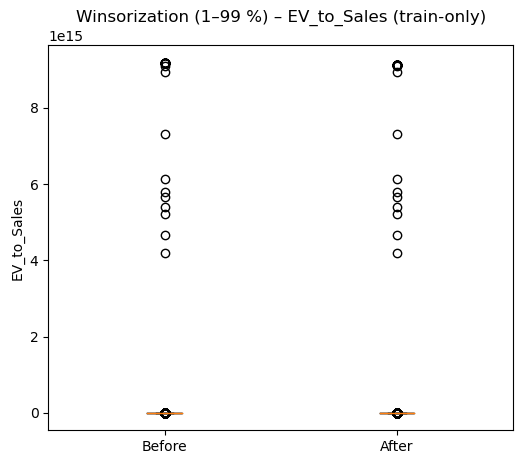

Train/Test shapes: (3163, 189) (791, 189)


In [7]:
# Cell 6 — EIN Split + train-only Preprocessing
X_train, X_test, y_train, y_test = train_test_split(
    X_safe.astype("float32"), y, test_size=0.2, random_state=42, shuffle=True
)

# Train-only Imputation
med = X_train.median(numeric_only=True)
X_train = X_train.fillna(med)
X_test  = X_test.fillna(med)

# Train-only Winsorizing (1.–99.%)
low_q = X_train.quantile(0.01)
high_q = X_train.quantile(0.99)
X_train = X_train.clip(lower=low_q, upper=high_q, axis=1)
X_test  = X_test.clip(lower=low_q, upper=high_q, axis=1)

import pandas as pd
import matplotlib.pyplot as plt

FEATURE = "EV_to_Sales"   # << kannst du nach Bedarf ändern

# Vorher-Daten (Kopie!)
before = X_train[FEATURE].copy()

# Winsorisierung anwenden (train-only Quantile!)
low_q = X_train[FEATURE].quantile(0.01)
high_q = X_train[FEATURE].quantile(0.99)
after = before.clip(lower=low_q, upper=high_q)

# Tabelle: Vorher/Nachher Kennzahlen
stats = pd.DataFrame({
    "Before": before.describe(percentiles=[.01,.25,.5,.75,.99]).round(3),
    "After": after.describe(percentiles=[.01,.25,.5,.75,.99]).round(3)
})
display(stats)

# Boxplot
plt.figure(figsize=(6,5))
plt.boxplot([before, after], labels=["Before", "After"])
plt.title(f"Winsorization (1–99 %) – {FEATURE} (train-only)")
plt.ylabel(FEATURE)
plt.show()
print("Train/Test shapes:", X_train.shape, X_test.shape)

# 7) Feature Selection

In [8]:
# Cell 7 — Selection on TRAIN only
xgb = XGBRegressor(
    n_estimators=400, learning_rate=0.05, max_depth=4,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1, importance_type="gain"
)
xgb.fit(X_train, y_train)

imp_series = pd.Series(xgb.feature_importances_, index=X_train.columns).sort_values(ascending=False)
mi = mutual_info_regression(X_train, y_train, random_state=42)
mi_series = pd.Series(mi, index=X_train.columns).sort_values(ascending=False)

# Kandidaten: Top 25 aus beiden
combined = pd.Index(mi_series.head(25).index).union(imp_series.head(25).index)

# Konfliktregel: Behalte bei hoher Interkorrelation das Feature mit höherem |corr(feature,y)|
corr_y = X_train.corrwith(y_train).fillna(0).abs()

# DataFrame aus allen drei Kennzahlen
df_features = pd.DataFrame({
    "feature": combined,
    "xgb_importance": imp_series.reindex(combined),
    "mutual_info": mi_series.reindex(combined),
    "corr_abs_with_y": corr_y.reindex(combined)
})

# Nach Wichtiger Sortieren (z.B. XGBoost Importance)
df_features = df_features.sort_values("xgb_importance", ascending=False).reset_index(drop=True)

display(df_features)

K = 12
THR = 0.55
selected = []

for c in combined:
    replace_idx = None
    for i, s in enumerate(selected):
        r = X_train[[c, s]].corr().iloc[0,1]
        if np.isfinite(r) and abs(r) >= THR:
            if corr_y.get(c, 0) > corr_y.get(s, 0):
                replace_idx = i   # ersetze s durch c
            else:
                replace_idx = -1  # verwerfe c
            break
    if replace_idx is None:
        selected.append(c)
    elif replace_idx >= 0:
        selected[replace_idx] = c
    if len(selected) >= K:
        break

selected, len(selected)

,feature,xgb_importance,mutual_info,corr_abs_with_y
0,Gross_Profit,0.148922,0.051820,0.191470
1,EBITDA,0.084419,0.060073,0.205206
2,Operating_Cash_Flow,0.044303,0.054446,0.206329
3,Net_Income_Com,0.041957,0.051562,0.210654
4,Total_shareholders_equity,0.037132,0.044927,0.193672
5,Earnings_before_Tax,0.023854,0.045167,0.209647
6,Weighted_Average_Shs_Out_Dil,0.018371,0.059455,0.176936
7,Stock_based_compensation,0.017086,0.222796,0.072377
8,EBIT,0.016519,0.051713,0.205549
9,Dividend_payments,0.013219,0.067384,0.187677


(['10Y_Dividend_per_Share_Growth_per_Share',
  '10Y_Operating_CF_Growth_per_Share',
  '5Y_Net_Income_Growth_per_Share',
  '5Y_Operating_CF_Growth_per_Share',
  '5Y_Revenue_Growth_per_Share',
  'Acquisitions_and_disposals',
  'Earnings_before_Tax',
  'Dividend_Yield',
  'EBITDA_Margin',
  'EV_to_Sales',
  'Graham_Net_Net',
  'Issuance_buybacks_of_shares'],
 12)

# 8) HeatMap for Correlation 

Maximale paarweise Korrelation (|ρ|, train-only): 0.470

Korrelation der Features mit dem Target (Market Cap) (train-only):


,Korrelation mit Market Cap,Richtung
Earnings_before_Tax,0.21,positiv
Acquisitions_and_disposals,-0.13,negativ
Issuance_buybacks_of_shares,-0.13,negativ
EBITDA_Margin,0.12,positiv
10Y_Dividend_per_Share_Growth_per_Share,0.09,positiv
5Y_Net_Income_Growth_per_Share,0.08,positiv
10Y_Operating_CF_Growth_per_Share,0.07,positiv
Graham_Net_Net,0.07,positiv
5Y_Operating_CF_Growth_per_Share,0.06,positiv
5Y_Revenue_Growth_per_Share,0.04,positiv


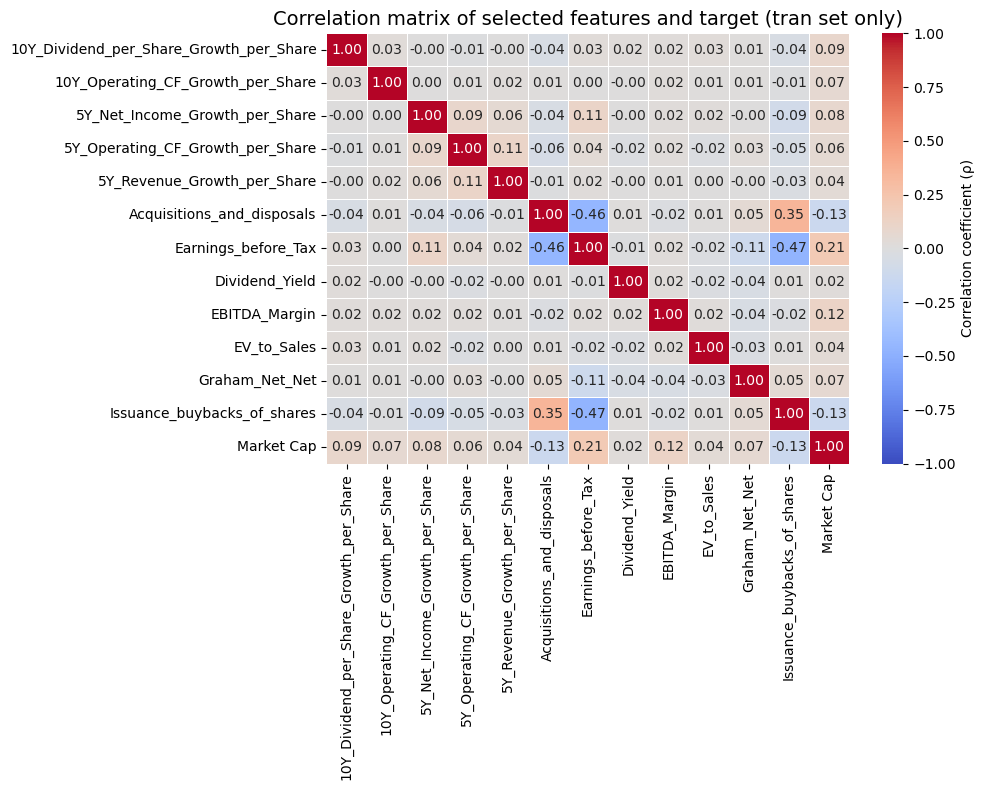

In [9]:
# === Volle Heatmap (ohne Mask) inkl. Target-Korrelation – TRAIN ONLY ===

# 1) Feature-Daten automatisch ermitteln (ohne feste Liste)
X_heat = (X_train_sel if 'X_train_sel' in locals()
          else X_train[selected] if ('selected' in locals() and 'X_train' in locals())
          else None)
if X_heat is None:
    raise NameError("Weder 'X_train_sel' noch ('selected' & 'X_train') vorhanden.")

# 2) y_train als Series mit passendem Index und Zielnamen
y_name = TARGET  # z.B. "Market Cap"
y_tr_s = pd.Series(y_train, index=X_heat.index, name=y_name)

# 3) Dataset für Korrelation: Features + Target
df_corr = pd.concat([X_heat, y_tr_s], axis=1)
# 3) Korrelationsmatrix
cm = df_corr.corr().round(2)

# 4) Max-|ρ| (ohne Diagonale) als Check
cm_abs = cm.abs()
max_corr = cm_abs.where(~np.eye(len(cm_abs), dtype=bool)).max().max()
print(f"Maximale paarweise Korrelation (|ρ|, train-only): {max_corr:.3f}")

# 5) Korrelation jedes Features mit dem Target (sortiert)
corr_with_y = cm[y_name].drop(y_name).sort_values(key=abs, ascending=False)
print(f"\nKorrelation der Features mit dem Target ({y_name}) (train-only):")

# In DataFrame umwandeln und Richtung ergänzen
corr_df = corr_with_y.to_frame(f"Korrelation mit {y_name}").round(3)
corr_df["Richtung"] = np.where(corr_with_y > 0, "positiv", "negativ")

# Ausgabe
display(corr_df)

# 6) Volle Heatmap (ohne Maskierung)
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, annot=True, fmt=".2f", cmap="coolwarm",
    vmin=-1, vmax=1, center=0, linewidths=0.5,
    cbar_kws={'label': 'Correlation coefficient (ρ)'}
)
plt.title("Correlation matrix of selected features and target (tran set only)", fontsize=14)
plt.tight_layout()
plt.show()

# 9) Final Subset & check train-only correlation

In [10]:
# Cell 8 — Subset + Korrelationscheck (train-only)
X_train_sel = X_train[selected].copy()
X_test_sel  = X_test[selected].copy()

cm = X_train_sel.corr().abs()
max_corr = cm.where(~np.eye(len(cm), dtype=bool)).max().max()

print(f"Max |ρ| (train-only): {max_corr:.3f}")

# Optionale Übersicht der Top-Paare
pairs = []
cols = cm.columns
for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        pairs.append((cols[i], cols[j], cm.iloc[i, j]))
pairs_sorted = sorted(pairs, key=lambda x: -x[2])
pairs_sorted[:5]

Max |ρ| (train-only): 0.471


[('Earnings_before_Tax', 'Issuance_buybacks_of_shares', 0.4711408845467678),
 ('Acquisitions_and_disposals', 'Earnings_before_Tax', 0.46047191323646935),
 ('Acquisitions_and_disposals',
  'Issuance_buybacks_of_shares',
  0.35246745160048015),
 ('5Y_Net_Income_Growth_per_Share',
  'Earnings_before_Tax',
  0.11311293694453294),
 ('5Y_Operating_CF_Growth_per_Share',
  '5Y_Revenue_Growth_per_Share',
  0.11264648082298691)]

# 10) Model & Pipeline

In [11]:
# ==========================================
# Cell 9 — OLS & XGB, Holdout + CV + Evaluationstabelle
# ==========================================

# === Modelle definieren ===
ols_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("qt", QuantileTransformer(output_distribution='normal', random_state=42, subsample=1_000_000)),
    ("scaler", StandardScaler()),
    ("ols", LinearRegression())
])

xgb_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("qt", QuantileTransformer(output_distribution='normal', random_state=42, subsample=1_000_000)),
    ("xgb", XGBRegressor(
        n_estimators=600, learning_rate=0.05, max_depth=4,
        subsample=0.9, colsample_bytree=0.9, random_state=42, n_jobs=-1
    ))
])

# === Holdout Fit ===
ols_pipe.fit(X_train_sel, y_train)
xgb_pipe.fit(X_train_sel, y_train)

# === Koeffizienten der linearen Regression ===
coef = ols_pipe.named_steps["ols"].coef_
coef_df = pd.DataFrame({
    "Feature": X_train_sel.columns,
    "Koeffizient": coef,
    "Vorzeichen": ["positiv" if c >= 0 else "negativ" for c in coef]
})
coef_df = coef_df.reindex(coef_df["Koeffizient"].abs().sort_values(ascending=False).index)

print("\n--- Koeffizienten der linearen Regression ---")
display(coef_df.round(4))

if (coef_df["Koeffizient"] < 0).any():
    print("\n⚠️  Hinweis: Es gibt negative Koeffizienten.")
else:
    print("\n✅  Alle Koeffizienten sind positiv.")

# === Holdout Evaluation ===
y_pred_lr  = ols_pipe.predict(X_test_sel)
y_pred_xgb = xgb_pipe.predict(X_test_sel)

r2_lr   = r2_score(y_test, y_pred_lr)
r2_xgb  = r2_score(y_test, y_pred_xgb)
mae_lr  = mean_absolute_error(y_test, y_pred_lr)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_lr = mean_squared_error(y_test, y_pred_lr, squared=False)
rmse_xgb = mean_squared_error(y_test, y_pred_xgb, squared=False)

impr = (r2_xgb - r2_lr) / max(1e-9, abs(r2_lr)) * 100

print("\n=== Modellbewertung (Holdout-Testdaten) ===")
print(f"OLS:  R² = {r2_lr:.3f} | MAE = {mae_lr:,.2f} | RMSE = {rmse_lr:,.2f}")
print(f"XGB:  R² = {r2_xgb:.3f} | MAE = {mae_xgb:,.2f} | RMSE = {rmse_xgb:,.2f}")
print(f"ΔR² (%-Verbesserung): {impr:.2f}%")

# === 10-fold Cross Validation (R²) ===
cv = KFold(n_splits=10, shuffle=True, random_state=42)
cv_ols = cross_val_score(ols_pipe, X_safe[selected], y, cv=cv, scoring="r2", n_jobs=-1)
cv_xgb = cross_val_score(xgb_pipe, X_safe[selected], y, cv=cv, scoring="r2", n_jobs=-1)

print("\n=== Cross-Validation (10-fold) ===")
print(f"CV R² OLS : mean = {cv_ols.mean():.3f} ± {cv_ols.std():.3f}")
print(f"CV R² XGB : mean = {cv_xgb.mean():.3f} ± {cv_xgb.std():.3f}")
print(f"Δ% (relative improvement): {((cv_xgb.mean() - cv_ols.mean()) / max(1e-9, abs(cv_ols.mean())) * 100):.2f}%")

# === Zusammenfassung in Tabelle ===
eval_df = pd.DataFrame({
    "Modell": ["OLS (Linear Regression)", "XGBoost Regressor"],
    "R² Holdout": [r2_lr, r2_xgb],
    "MAE Holdout": [mae_lr, mae_xgb],
    "RMSE Holdout": [rmse_lr, rmse_xgb],
    "CV R² Mean": [cv_ols.mean(), cv_xgb.mean()],
    "CV R² Std": [cv_ols.std(), cv_xgb.std()]
}).round(3)

display(eval_df)

print("\n=== Zusammenfassung der Modellbewertung ===")
display(eval_df.style.highlight_max(axis=0, color="lightgreen"))


--- Koeffizienten der linearen Regression ---


,Feature,Koeffizient,Vorzeichen
6,Earnings_before_Tax,0.9914,positiv
9,EV_to_Sales,0.3582,positiv
5,Acquisitions_and_disposals,-0.3075,negativ
4,5Y_Revenue_Growth_per_Share,0.1769,positiv
7,Dividend_Yield,0.1513,positiv
0,10Y_Dividend_per_Share_Growth_per_Share,0.1465,positiv
11,Issuance_buybacks_of_shares,-0.1424,negativ
1,10Y_Operating_CF_Growth_per_Share,0.1178,positiv
10,Graham_Net_Net,-0.1030,negativ
3,5Y_Operating_CF_Growth_per_Share,0.0558,positiv



⚠️  Hinweis: Es gibt negative Koeffizienten.

=== Modellbewertung (Holdout-Testdaten) ===
OLS:  R² = 0.364 | MAE = 1.35 | RMSE = 2.00
XGB:  R² = 0.654 | MAE = 0.77 | RMSE = 1.48
ΔR² (%-Verbesserung): 79.64%

=== Cross-Validation (10-fold) ===
CV R² OLS : mean = 0.343 ± 0.061
CV R² XGB : mean = 0.611 ± 0.104
Δ% (relative improvement): 78.01%


,Modell,R² Holdout,MAE Holdout,RMSE Holdout,CV R² Mean,CV R² Std
0,OLS (Linear Regression),0.364,1.353,2.001,0.343,0.061
1,XGBoost Regressor,0.654,0.765,1.475,0.611,0.104



=== Zusammenfassung der Modellbewertung ===


,Modell,R² Holdout,MAE Holdout,RMSE Holdout,CV R² Mean,CV R² Std
0,OLS (Linear Regression),0.364000,1.353000,2.001000,0.343000,0.061000
1,XGBoost Regressor,0.654000,0.765000,1.475000,0.611000,0.104000


# 11) Global SHAP Analysis

In [12]:
#!pip install shap

PermutationExplainer explainer: 792it [00:39, 15.17it/s]                        


X_test_pp shape: (791, 12)
shap_values_test shape: (791, 12)


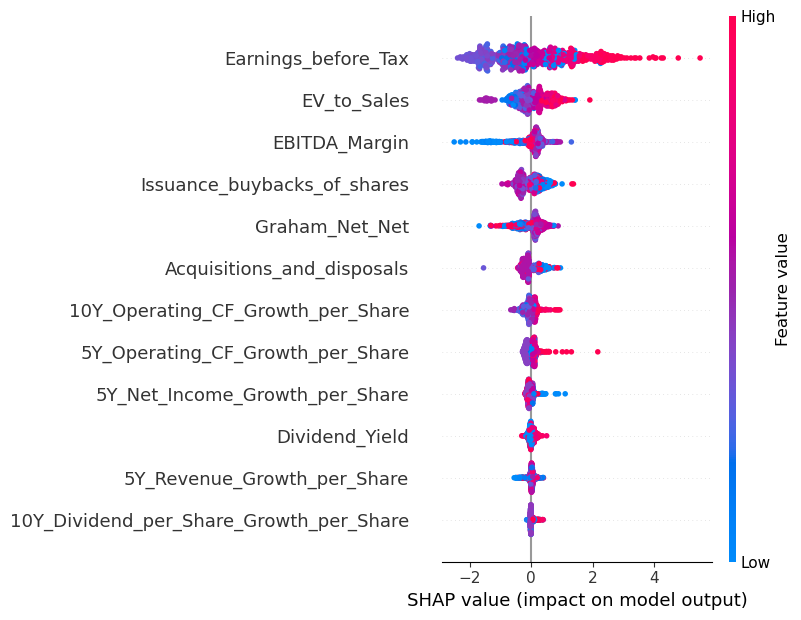

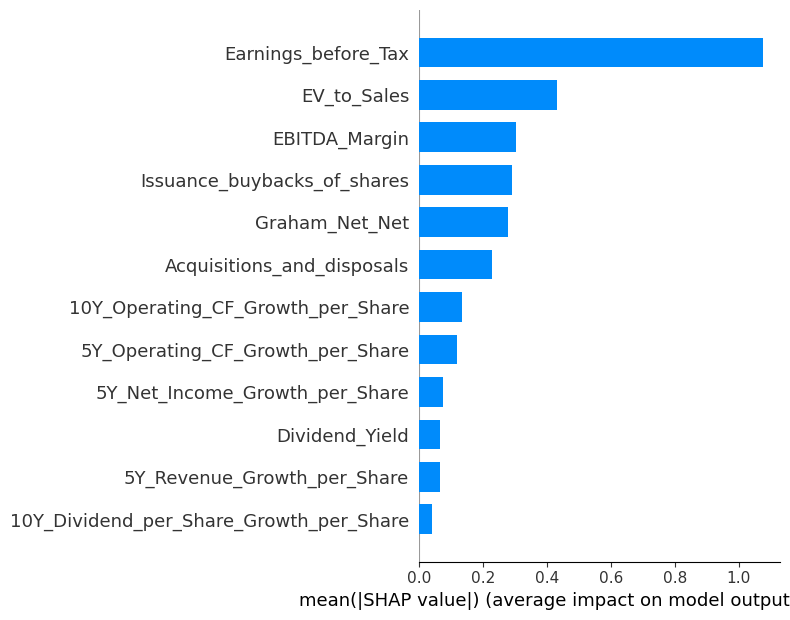


=== Globale SHAP-Importance (Testdaten) ===


,Feature,mean_|SHAP|
0,Earnings_before_Tax,1.0754
1,EV_to_Sales,0.4331
2,EBITDA_Margin,0.3020
3,Issuance_buybacks_of_shares,0.2918
4,Graham_Net_Net,0.2783
5,Acquisitions_and_disposals,0.2280
6,10Y_Operating_CF_Growth_per_Share,0.1333
7,5Y_Operating_CF_Growth_per_Share,0.1199
8,5Y_Net_Income_Growth_per_Share,0.0758
9,Dividend_Yield,0.0662


In [13]:
# === 1) Preprocessing-Teil der Pipeline extrahieren ===
preprocess_xgb = Pipeline(xgb_pipe.steps[:-1]) 

# === 2) Transformierte Daten (wie im Modell) ===
X_train_pp = preprocess_xgb.transform(X_train_sel)
X_test_pp  = preprocess_xgb.transform(X_test_sel)

# 3) SHAP-Explainer für das XGBoost-Modell (robust, mit callable)

model_xgb = xgb_pipe.named_steps["xgb"]

# Vorhersagefunktion definieren (für SHAP „callable“ machen)
f_xgb = lambda data: model_xgb.predict(data)

explainer = shap.Explainer(
    f_xgb,
    X_train_pp,
    feature_names=list(X_train_sel.columns)   
)

# === 4) SHAP-Werte für Testdaten berechnen ===
shap_exp_test = explainer(X_test_pp)  
shap_values_test = shap_exp_test.values  # reines numpy-Array (n_samples x n_features)

print("X_test_pp shape:", X_test_pp.shape)
print("shap_values_test shape:", shap_values_test.shape)

# 5) Globaler SHAP Summary Plot (Punkteplot)
shap.summary_plot(
    shap_values_test,
    X_test_pp,
    feature_names=X_train_sel.columns,
    show=True
)

# 6) Globaler SHAP Summary Plot (Balkenplot nach mittlerem |SHAP|-Wert)
shap.summary_plot(
    shap_values_test,
    X_test_pp,
    feature_names=X_train_sel.columns,
    plot_type="bar",
    show=True
)

# 7) Tabelle der mittleren absoluten SHAP-Werte 
mean_abs_shap = np.abs(shap_values_test).mean(axis=0)
shap_importance_df = (
    pd.DataFrame({
        "Feature": X_train_sel.columns,
        "mean_|SHAP|": mean_abs_shap
    })
    .sort_values("mean_|SHAP|", ascending=False)
    .reset_index(drop=True)
)

print("\n=== Globale SHAP-Importance (Testdaten) ===")
display(shap_importance_df.round(4))

# 12) Comparison of OLS Coefficients vs. global SHAP-Importance

=== Vergleich OLS vs. SHAP (global) ===


,Feature,Koeffizient,Vorzeichen,abs_beta,mean_|SHAP|,Rank_OLS_abs,Rank_SHAP
0,Earnings_before_Tax,0.9914,positiv,0.9914,1.0754,1,1
1,EV_to_Sales,0.3582,positiv,0.3582,0.4331,2,2
2,EBITDA_Margin,-0.0152,negativ,0.0152,0.3020,11,3
3,Issuance_buybacks_of_shares,-0.1424,negativ,0.1424,0.2918,7,4
4,Graham_Net_Net,-0.1030,negativ,0.1030,0.2783,9,5
5,Acquisitions_and_disposals,-0.3075,negativ,0.3075,0.2280,3,6
6,10Y_Operating_CF_Growth_per_Share,0.1178,positiv,0.1178,0.1333,8,7
7,5Y_Operating_CF_Growth_per_Share,0.0558,positiv,0.0558,0.1199,10,8
8,5Y_Net_Income_Growth_per_Share,-0.0087,negativ,0.0087,0.0758,12,9
9,Dividend_Yield,0.1513,positiv,0.1513,0.0662,5,10



Spearman-Korrelation zwischen |OLS-Koeffizient| und mean_|SHAP|: 0.224
p-Wert: 0.4845


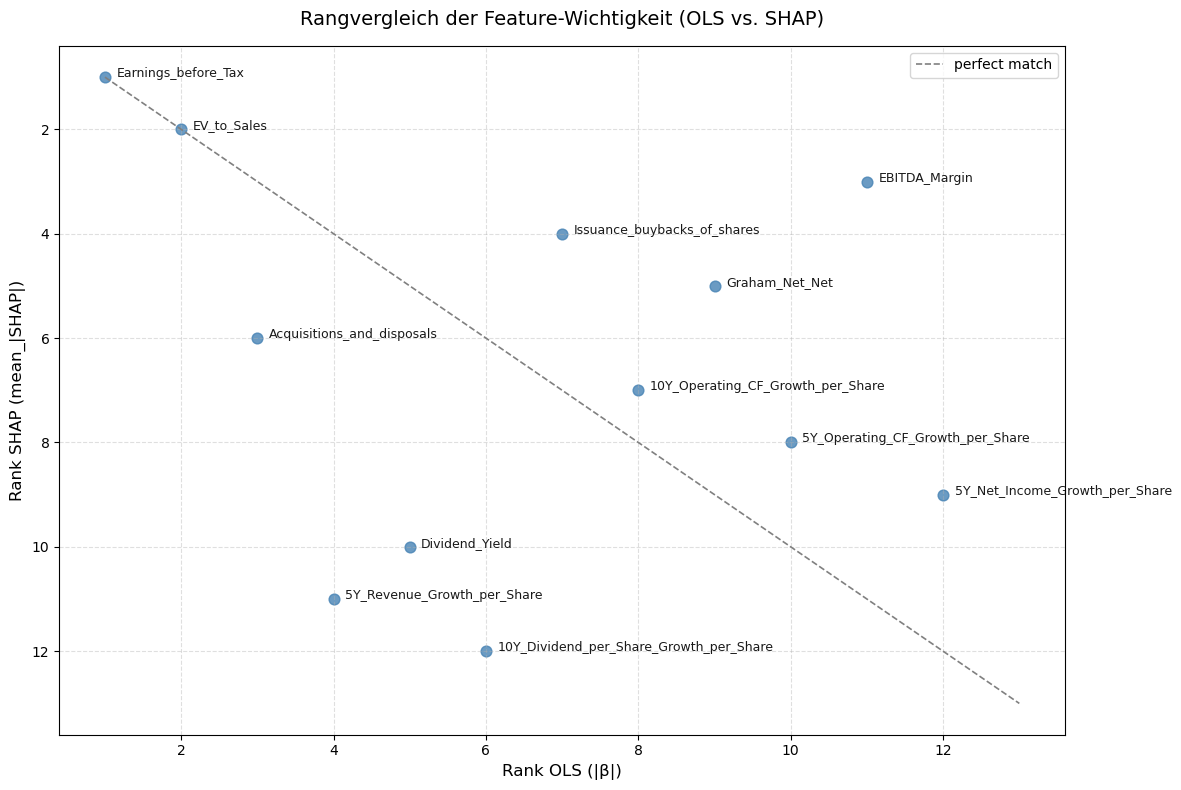

In [14]:
# 1) Relevante Spalten aus den beiden Tabellen auswählen
ols_for_merge = coef_df[["Feature", "Koeffizient"]].copy()
shap_for_merge = shap_importance_df[["Feature", "mean_|SHAP|"]].copy()

# 2) Zu einer gemeinsamen Vergleichstabelle mergen
comp_df = (
    ols_for_merge
    .merge(shap_for_merge, on="Feature", how="inner")
)

# 3) Betrag der OLS-Koeffizienten und Vorzeichen ergänzen
comp_df["abs_beta"] = comp_df["Koeffizient"].abs()
comp_df["Vorzeichen"] = np.where(comp_df["Koeffizient"] >= 0, "positiv", "negativ")

# 4) Ränge nach OLS- und SHAP-Bedeutung bestimmen 
comp_df["Rank_OLS_abs"] = comp_df["abs_beta"].rank(ascending=False).astype(int)
comp_df["Rank_SHAP"]    = comp_df["mean_|SHAP|"].rank(ascending=False).astype(int)

# 5) Nach SHAP-Importance sortieren 
comp_df = comp_df.sort_values("mean_|SHAP|", ascending=False).reset_index(drop=True)

print("=== Vergleich OLS vs. SHAP (global) ===")
display(comp_df[[
    "Feature",
    "Koeffizient",
    "Vorzeichen",
    "abs_beta",
    "mean_|SHAP|",
    "Rank_OLS_abs",
    "Rank_SHAP"
]].round(4))

# 6) Spearman-Korrelation zwischen |β| und mean_|SHAP|
rho_spear, p_spear = spearmanr(comp_df["abs_beta"], comp_df["mean_|SHAP|"])

print(f"\nSpearman-Korrelation zwischen |OLS-Koeffizient| und mean_|SHAP|: {rho_spear:.3f}")
print(f"p-Wert: {p_spear:.4f}")


plt.figure(figsize=(12, 8))

# Scatterpunkte
plt.scatter(comp_df["Rank_OLS_abs"], comp_df["Rank_SHAP"], s=60, color="steelblue", alpha=0.8)

# Diagonale (perfekte Übereinstimmung)
max_rank = max(comp_df["Rank_OLS_abs"].max(), comp_df["Rank_SHAP"].max()) + 1
plt.plot([1, max_rank], [1, max_rank], color="gray", linestyle="--", linewidth=1.2, label="perfect match")

# Textbeschriftungen
for _, row in comp_df.iterrows():
    plt.text(
        row["Rank_OLS_abs"] + 0.15, 
        row["Rank_SHAP"], 
        row["Feature"], 
        fontsize=9, 
        alpha=0.9
    )

# Achsen & Layout
plt.xlabel("Rank OLS (|β|)", fontsize=12)
plt.ylabel("Rank SHAP (mean_|SHAP|)", fontsize=12)
plt.title("Rangvergleich der Feature-Wichtigkeit (OLS vs. SHAP)", fontsize=14, pad=15)
plt.gca().invert_yaxis()  # kleinere Ränge oben
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

# 13) SHAP Analysis (local) with practical Example

In [15]:
# ==========================================
# 4.4 Lokale SHAP-Analyse (Vorbereitung)
# ==========================================

# Vorhersagen auf Testdaten
y_pred_xgb = xgb_pipe.predict(X_test_sel)

# Realskala + Hilfs-DataFrame
res_test = pd.DataFrame({
    "y_true_log": y_test.values,
    "y_pred_log": y_pred_xgb
}, index=np.arange(len(y_test)))

res_test["y_true"] = np.expm1(res_test["y_true_log"])
res_test["y_pred"] = np.expm1(res_test["y_pred_log"])

print("Überblick Test-Set (reale Skala, Market Cap):")
display(res_test[["y_true", "y_pred"]].describe().round(2))

# Repräsentative Indizes bestimmen
idx_high = res_test["y_pred_log"].idxmax()
idx_low  = res_test["y_pred_log"].idxmin()
idx_mid  = res_test["y_pred_log"].sort_values().index[len(res_test)//2]

print(f"\nIndex high : {idx_high}, vorhergesagte Market Cap (log) = {res_test.loc[idx_high, 'y_pred_log']:.3f}")
print(f"Index mid  : {idx_mid},  vorhergesagte Market Cap (log) = {res_test.loc[idx_mid,  'y_pred_log']:.3f}")
print(f"Index low  : {idx_low},  vorhergesagte Market Cap (log) = {res_test.loc[idx_low,  'y_pred_log']:.3f}")

Überblick Test-Set (reale Skala, Market Cap):


,y_true,y_pred
count,7.910000e+02,7.910000e+02
mean,6.712076e+13,3.177614e+10
std,1.370530e+15,5.320290e+11
min,1.773250e+06,1.725628e+06
25%,2.010725e+08,2.125562e+08
50%,9.687332e+08,8.803473e+08
75%,4.601240e+09,4.247729e+09
max,3.310696e+16,1.388732e+13



Index high : 534, vorhergesagte Market Cap (log) = 30.262
Index mid  : 577,  vorhergesagte Market Cap (log) = 20.596
Index low  : 78,  vorhergesagte Market Cap (log) = 14.361


In [16]:
# ==========================================
# Hilfsfunktion für lokale SHAP-Analysen
# ==========================================

def show_local_shap(idx, title_prefix="Beispiel", max_features=12):
    """
    Zeigt lokale SHAP-Erklärung für eine einzelne Beobachtung:
    - echte & vorhergesagte Market Cap
    - Top-Featurebeiträge (SHAP)
    - Waterfall-Plot
    """
    print(f"\n===== {title_prefix} (Index {idx}) =====")
    print(f"y_true_log = {res_test.loc[idx, 'y_true_log']:.3f}")
    print(f"y_pred_log = {res_test.loc[idx, 'y_pred_log']:.3f}")
    print(f"y_true ≈ {res_test.loc[idx, 'y_true']:.2f}")
    print(f"y_pred ≈ {res_test.loc[idx, 'y_pred']:.2f}")

    # Featurewerte und SHAP-Werte
    
    x_row = X_test_sel.iloc[idx].to_frame(name="Feature-Wert")
    shap_row = shap_exp_test.values[idx]
    
    local_df = pd.DataFrame({
        "Feature": X_train_sel.columns,
        "SHAP": shap_row
    }).set_index("Feature")
    local_df["|SHAP|"] = local_df["SHAP"].abs()
    local_df = local_df.join(x_row, how="left")

    # Nach Stärke sortieren
    local_top = local_df.sort_values("|SHAP|", ascending=False).head(max_features)

    print("\nTop-Featurebeiträge (lokal):")
    display(local_top[["Feature-Wert", "SHAP", "|SHAP|"]].round(4))

    # Visualisierung
    shap.plots.waterfall(shap_exp_test[idx], max_display=max_features)


===== Fall A: hohe vorhergesagte Market Cap (Index 534) =====
y_true_log = 27.724
y_pred_log = 30.262
y_true ≈ 1097648982760.00
y_pred ≈ 13887318523904.00

Top-Featurebeiträge (lokal):


,Feature-Wert,SHAP,|SHAP|
Feature,,,
Earnings_before_Tax,7.290300e+10,4.7760,4.7760
EV_to_Sales,4.314200e+04,1.0824,1.0824
Issuance_buybacks_of_shares,-7.206900e+10,1.0001,1.0001
10Y_Operating_CF_Growth_per_Share,2.595000e-01,0.8813,0.8813
EBITDA_Margin,3.160000e+02,0.7953,0.7953
Acquisitions_and_disposals,-7.210000e+08,0.4709,0.4709
Graham_Net_Net,-1.159000e-01,0.2945,0.2945
5Y_Operating_CF_Growth_per_Share,1.353000e-01,0.1610,0.1610
5Y_Net_Income_Growth_per_Share,1.601000e-01,0.0852,0.0852


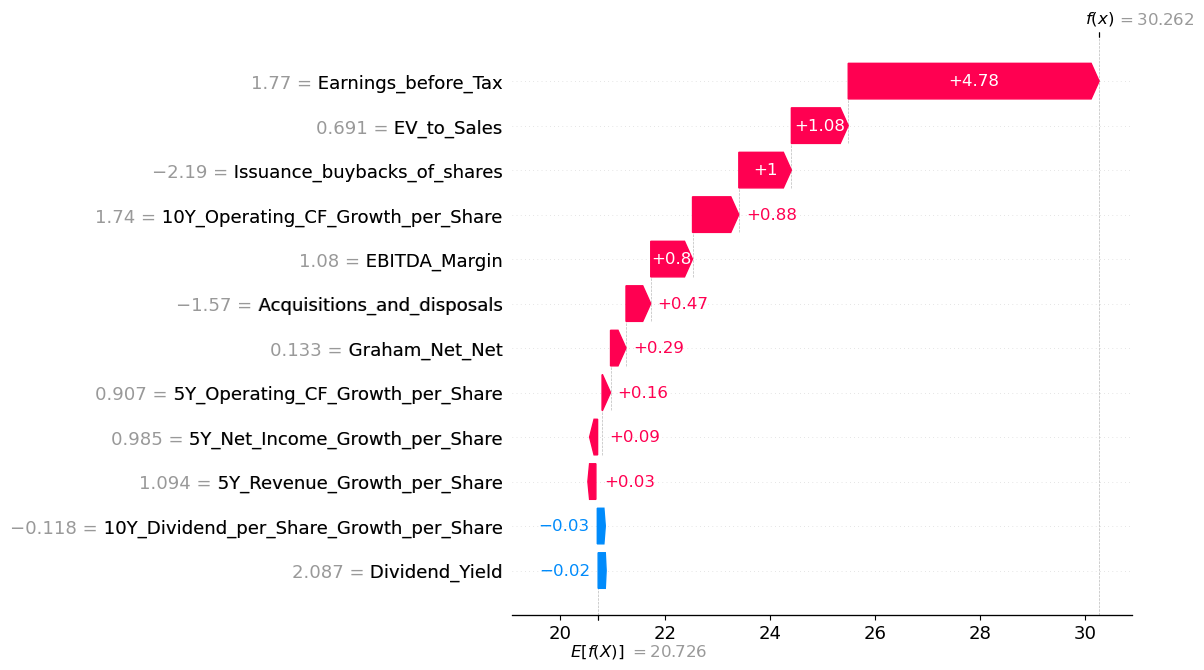

In [17]:
# ==========================================
# Lokale Analyse (hohe Market Cap)
# ==========================================

show_local_shap(idx_high, title_prefix="Fall A: hohe vorhergesagte Market Cap", max_features=12)


===== Fall B: mittlere vorhergesagte Market Cap (Index 577) =====
y_true_log = 20.749
y_pred_log = 20.596
y_true ≈ 1026102335.12
y_pred ≈ 880347328.00

Top-Featurebeiträge (lokal):


,Feature-Wert,SHAP,|SHAP|
Feature,,,
EBITDA_Margin,3.100000e+01,0.7096,0.7096
Earnings_before_Tax,3.700000e+07,-0.5688,0.5688
EV_to_Sales,3.919000e-01,-0.5509,0.5509
Issuance_buybacks_of_shares,0.000000e+00,-0.3565,0.3565
Acquisitions_and_disposals,-7.800000e+07,0.3182,0.3182
Graham_Net_Net,-4.970000e-02,0.1955,0.1955
5Y_Operating_CF_Growth_per_Share,-5.128000e+01,0.1015,0.1015
5Y_Net_Income_Growth_per_Share,-2.046000e-01,0.0824,0.0824
Dividend_Yield,1.990000e-02,-0.0452,0.0452


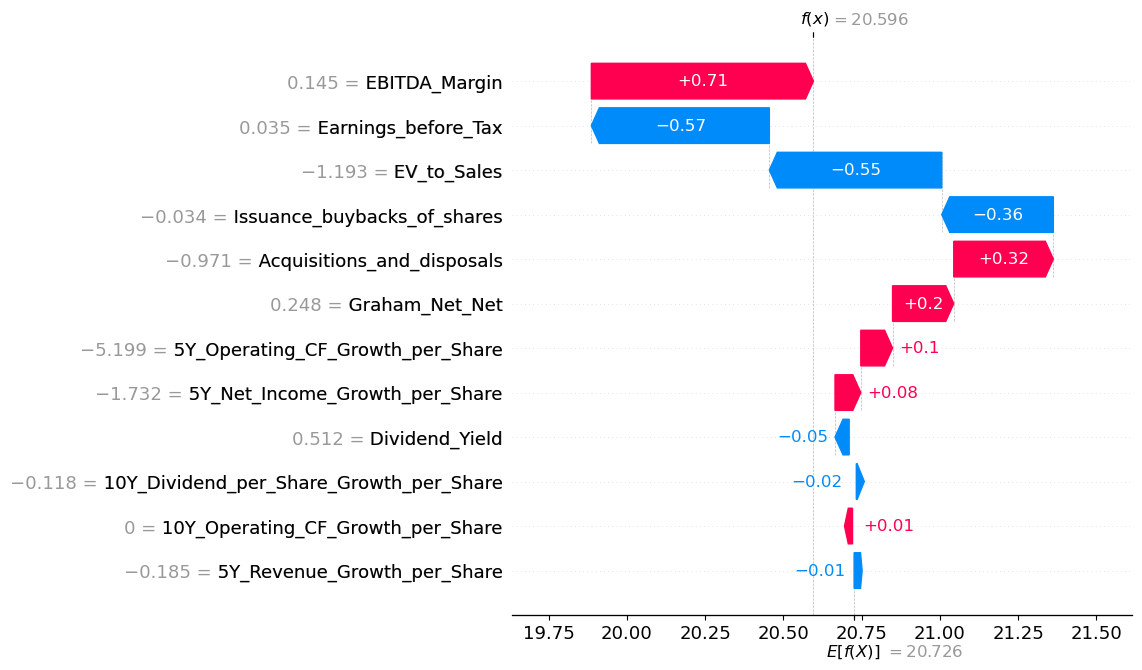

In [18]:
# ==========================================
# Lokale Analyse (mittlere Market Cap)
# ==========================================
show_local_shap(idx_mid,  title_prefix="Fall B: mittlere vorhergesagte Market Cap", max_features=12)


===== Fall C: niedrige vorhergesagte Market Cap (Index 78) =====
y_true_log = 15.847
y_pred_log = 14.361
y_true ≈ 7623442.67
y_pred ≈ 1725627.88

Top-Featurebeiträge (lokal):


,Feature-Wert,SHAP,|SHAP|
Feature,,,
Earnings_before_Tax,-8.625000e+06,-2.0719,2.0719
EBITDA_Margin,-1.618100e+16,-1.3989,1.3989
Graham_Net_Net,1.894316e+04,-1.0638,1.0638
Issuance_buybacks_of_shares,6.300000e+05,-0.5230,0.5230
Acquisitions_and_disposals,0.000000e+00,-0.4015,0.4015
5Y_Revenue_Growth_per_Share,-1.000000e+00,-0.2942,0.2942
10Y_Operating_CF_Growth_per_Share,0.000000e+00,-0.1745,0.1745
5Y_Operating_CF_Growth_per_Share,0.000000e+00,-0.1702,0.1702
EV_to_Sales,0.000000e+00,-0.0946,0.0946


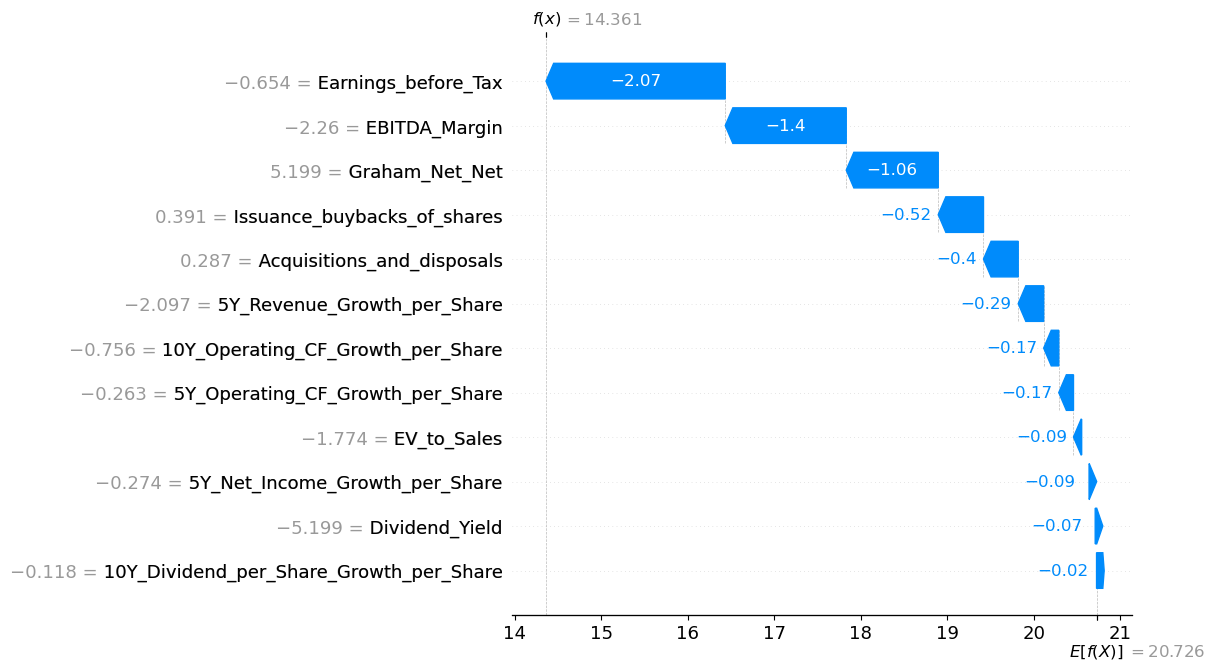

In [19]:
# ==========================================
# Lokale Analyse (niedrige Market Cap)
# ==========================================

show_local_shap(idx_low, title_prefix="Fall C: niedrige vorhergesagte Market Cap", max_features=12)